# Libraries and CSV Load

In [119]:
# Install PyAgrum
!pip install pyagrum --quiet

# Imports
import pandas as pd
import numpy as np
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import random

# Reproducibility
r_seed = 101
gum.initRandom(r_seed)
random.seed(r_seed)

# Load In CSV
df = pd.read_csv('/content/Sleep_Health_Lifestyle.csv')

# All Occupations and Node Lists

In [120]:
# Show All Available Occupations
all_occupations = sorted(df['Occupation'].dropna().unique())

# Print All Available Occupations
print("Available Occupations in Dataset:")
for occ in all_occupations:
    print(f"- {occ}")

# Define For State Orders
STATE_ORDERS = {
    'Sleep Duration': ['Short', 'Normal', 'Long'],
    'Quality of Sleep': ['Low', 'Normal', 'Good'],
    'Physical Activity Level': ['Low', 'Moderate', 'High'],
    'Stress Level': ['Low', 'Normal', 'High'],
    'BMI Category': ['Underweight', 'Normal', 'Overweight', 'Obese'],
    'Blood Pressure': ['Normal', 'Elevated', 'High (Stage 1)', 'High (Stage 2)'],
    'Heart Rate': ['Low', 'Normal', 'High'],
    'Daily Steps': ['Low', 'Moderate', 'High'],
    'Sleep Disorder': ['None', 'Insomnia', 'Sleep Apnea', 'Other']
}

Available Occupations in Dataset:
- Accountant
- Doctor
- Engineer
- Lawyer
- Manager
- Nurse
- Sales Representative
- Salesperson
- Scientist
- Software Engineer
- Teacher


# User Configuration

## Bayesian Network 1

In [121]:
# User Configuration
INPUT_1 = 'Occupation'
INPUT_2 = 'Demographic'
TARGET = 'Stress Level'
OUTPUT_1 = 'Heart Rate'
OUTPUT_2 = 'Quality of Sleep'
SELECTED_OCCUPATIONS = ['Doctor', 'Engineer', 'Teacher']

# Scenarios
SCENARIOS = [
    {
        "name": "Scenario 1: Male Doctor (20-40)",
        "evidence": {
            INPUT_1: 'Doctor',
            INPUT_2: 'Male 20-40'
        },
        "targets": [TARGET]
    },
    {
        "name": "Scenario 2: High Stress Teacher",
        "evidence": {
            INPUT_1: 'Teacher',
            TARGET: 'High'
        },
        "targets": [OUTPUT_1]
    }
]

## Bayesian Network 2

In [122]:
# # User Configuration
# INPUT_1 = 'Occupation'
# INPUT_2 = 'Sleep Duration'
# TARGET = 'Stress Level'
# OUTPUT_1 = 'Daily Steps'
# OUTPUT_2 = 'Blood Pressure'
# SELECTED_OCCUPATIONS = ['Scientist', 'Nurse', 'Accountant', 'Salesperson']

# # Scenarios
# SCENARIOS = [
#     {
#         "name": "Scenario 3: Accountant Moderate Steps and Normal Sleep",
#         "evidence": {
#             OUTPUT_1: 'Moderate',
#             INPUT_2: 'Normal'
#         },
#         "targets": [INPUT_1]
#     },
#     {
#         "name": "Scenario 4: High (Stage 1) Blood Pressure Nurse",
#         "evidence": {
#             INPUT_1: 'Nurse',
#             OUTPUT_2: 'High (Stage 1)'
#         },
#         "targets": [TARGET]
#     }
# ]

# Methods

In [123]:
# Blood Pressure Function
def bp_category(bp):
    try:
        systolic, diastolic = map(int, bp.split('/'))
        if systolic < 120 and diastolic < 80:
            return 'Normal'
        elif 120 <= systolic <= 129 and diastolic < 80:
            return 'Elevated'
        elif 130 <= systolic <= 139 or 80 <= diastolic <= 89:
            return 'High (Stage 1)'
        elif 140 <= systolic or 90 <= diastolic:
            return 'High (Stage 2)'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

# Prior Probability Function
def compute_prior(df, var):
    counts = df[var].value_counts(normalize=True).reset_index()
    counts.columns = [var, 'Probability']
    return counts

# Conditional Probability Function
def compute_conditional(df, parents, child):
    group_cols = parents + [child]
    counts = df.groupby(group_cols).size().reset_index(name='count')

    counts['Probability'] = counts.groupby(parents)['count'].transform(
        lambda x: x / x.sum()
    )
    return counts

# Add Variables Dynamically
def add_variable(bn, df, var):
    if var in STATE_ORDERS:
        states = STATE_ORDERS[var]
    else:
        states = sorted(df[var].dropna().unique())

    bn.add(gum.LabelizedVariable(var, '', states))

# Fill Output CPT Function
def fill_output_cpt(bn, df, counts, parent, child):
    for p in df[parent].unique():
        subset = counts[counts[parent] == p].set_index(child)['Probability']
        states = bn.variable(child).labels()

        bn.cpt(child)[{parent: p}] = [
            subset.get(state, 0) for state in states
        ]

# Catagories

In [124]:
# Age Catagories
df['Age'] = df['Age'].apply(
    lambda x: '20-40' if 20 <= x <= 40
    else '41-60'
)

# Age Demographic Catagories
conditions = [
    (df['Gender'] == 'Male') & (df['Age'] == '20-40'),
    (df['Gender'] == 'Male') & (df['Age'] == '41-60'),
    (df['Gender'] == 'Female') & (df['Age'] == '20-40'),
    (df['Gender'] == 'Female') & (df['Age'] == '41-60')
]

choices = ['Male 20-40', 'Male 41-60', 'Female 20-40', 'Female 41-60']
df['Demographic'] = np.select(conditions, choices, default='Other')

# Occupation Catagories
df = df[df['Occupation'].isin(SELECTED_OCCUPATIONS)]

# Sleep Duration Categories
df['Sleep Duration'] = df['Sleep Duration'].apply(
    lambda x: 'Short' if x < 6
    else 'Normal' if 6 <= x <= 8
    else 'Long'
)

# Quality of Sleep Catagories
df['Quality of Sleep'] = df['Quality of Sleep'].apply(
    lambda x: 'Low' if x <= 4
    else 'Normal' if 5 <= x <= 7
    else 'Good'
)

# Physical Activity Level Categories
df['Physical Activity Level'] = df['Physical Activity Level'].apply(
    lambda x: 'Low' if x < 30
    else 'Moderate' if 30 <= x <= 60
    else 'High'
)

# Stress Level Catagories
df['Stress Level'] = df['Stress Level'].apply(
    lambda x: 'Low' if x <= 4
    else 'Normal' if 5 <= x <= 7
    else 'High'
)

# BMI Category Cleanup and Catagories
df['BMI Category'] = df['BMI Category'].replace({
    'Normal Weight': 'Normal'
})

df['BMI Category'] = df['BMI Category'].apply(
    lambda x: 'Underweight' if x == 'Underweight'
    else 'Normal' if x == 'Normal'
    else 'Overweight' if x == 'Overweight'
    else 'Obese' if x == 'Obese'
    else 'Unknown'
)

# Blood Pressure Categories
df['Blood Pressure'] = df['Blood Pressure'].apply(bp_category)

# Heart Rate Catagories
df['Heart Rate'] = df['Heart Rate'].apply(
    lambda x: 'Low' if 40 <= x <= 65
    else 'Normal' if 66 <= x <= 72
    else 'High'
)

# Daily Steps Categories
df['Daily Steps'] = df['Daily Steps'].apply(
    lambda x: 'Low' if x < 5000
    else 'Moderate' if 5000 <= x <= 10000
    else 'High'
)

# Sleep Disorder Cleanup
df['Sleep Disorder'] = df['Sleep Disorder'].apply(
    lambda x: 'None' if x == 'None'
    else 'Insomnia' if x == 'Insomnia'
    else 'Sleep Apnea' if x == 'Sleep Apnea'
    else 'Other'
)

# Probabilities

In [125]:
# Compute Prior Probabilities
prior_1 = compute_prior(df, INPUT_1)
prior_2 = compute_prior(df, INPUT_2)

# Compute Target Conditional Probability
target_counts = compute_conditional(df, [INPUT_1, INPUT_2], TARGET)

# Compute Output Conditional Probabilities
output1_counts = compute_conditional(df, [TARGET], OUTPUT_1)
output2_counts = compute_conditional(df, [TARGET], OUTPUT_2)

# Bayesian Network

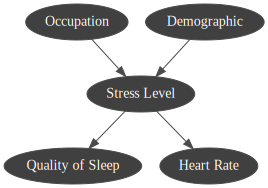

In [126]:
# Define BN
bn = gum.BayesNet('DynamicStressBN')

# Add Variables Dynamically
add_variable(bn, df, INPUT_1)
add_variable(bn, df, INPUT_2)
add_variable(bn, df, TARGET)
add_variable(bn, df, OUTPUT_1)
add_variable(bn, df, OUTPUT_2)

# Add Arcs Dynamically
bn.addArc(INPUT_1, TARGET)
bn.addArc(INPUT_2, TARGET)
bn.addArc(TARGET, OUTPUT_1)
bn.addArc(TARGET, OUTPUT_2)

# Show BN
gnb.showBN(bn)

# Conditional Probability Tables

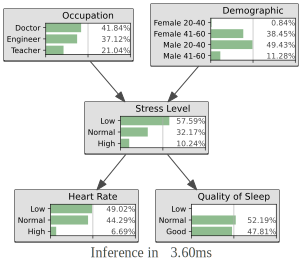

In [127]:
# Fill Prior 1 CPT
for _, row in prior_1.iterrows():
    bn.cpt(INPUT_1)[{INPUT_1: row[INPUT_1]}] = row['Probability']

# Fill Prior 2 CPT
for _, row in prior_2.iterrows():
    bn.cpt(INPUT_2)[{INPUT_2: row[INPUT_2]}] = row['Probability']

# Fill Target CPT
for val1 in df[INPUT_1].unique():
    for val2 in df[INPUT_2].unique():

        subset = target_counts[
            (target_counts[INPUT_1] == val1) &
            (target_counts[INPUT_2] == val2)
        ].set_index(TARGET)['Probability']

        states = bn.variable(TARGET).labels()

        bn.cpt(TARGET)[{
            INPUT_1: val1,
            INPUT_2: val2
        }] = [subset.get(state, 0) for state in states]

# Fill Output 1 CPT
fill_output_cpt(bn, df, output1_counts, TARGET, OUTPUT_1)

# Fill Output 2 CPT
fill_output_cpt(bn, df, output2_counts, TARGET, OUTPUT_2)

# Display All CPT's
gnb.showCPTs(bn)

# Display Inferenece Of BN
gnb.showInference(bn)

# Scenarios and Evidence


--- Scenario 1: Male Doctor (20-40) ---



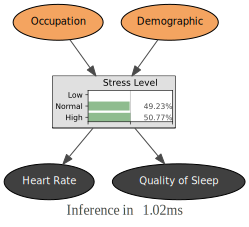


--- Scenario 2: High Stress Teacher ---



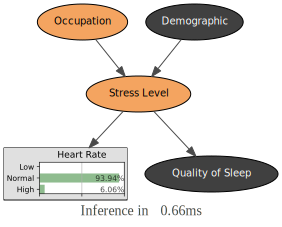

In [128]:
# Show Inference Scenarios
for scenario in SCENARIOS:
  print(f"\n--- {scenario['name']} ---\n")
  gnb.showInference(
      bn,
      evs=scenario["evidence"],
      targets=set(scenario["targets"])
  )